## Data Preprocessing and Exploratory Data Analysis

In [1]:
# Necessary libraries
import re # for regular expressions
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
import nltk # for natural language processing
import warnings

# Suppress Deprecation Warning category
warnings.filterwarnings("ignore", category = DeprecationWarning)

# Set a display option for how Pandas DataFrames will be shown when displayed;
pd.set_option('display.max_colwidth', 200) # max column width - 200 characters

# inline rendering of Matplotlib plots
%matplotlib inline

In [ ]:
# Load dataset
data = pd.read_csv('../data/interim/youtube_sentiments.csv')

Data Inspection

In [3]:
# Display the first five rows of the dataset
data.head()

,text,sentiment
0,"This was excellent, thank you both",1
1,Nice discussion!,1
2,thanks,1
3,"That&#39;s the way, did the same, smaller companies a LOT more experience since more responsibility, more control over frustrated things.",-1
4,Only weird people hate rto.,-1


In [4]:
# Shape of the dataset (how many rows and columns you have)
data.shape

(421404, 2)

In [5]:
# General info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421404 entries, 0 to 421403
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       421403 non-null  object
 1   sentiment  421404 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


In [6]:
# A few positive comments
data[data['sentiment'] == 1].head()

,text,sentiment
0,"This was excellent, thank you both",1
1,Nice discussion!,1
2,thanks,1
5,"Wow so nice, I need learn ❤",1
6,I am from India ❤,1


In [7]:
# A few negative comments
data[data['sentiment'] == -1].head()

,text,sentiment
3,"That&#39;s the way, did the same, smaller companies a LOT more experience since more responsibility, more control over frustrated things.",-1
4,Only weird people hate rto.,-1
33,Going straight into my Not Interested playlist.,-1
41,the worst part about this course is that it isn&#39;t practical,-1
43,But it&#39;s just lecture no coding,-1


In [8]:
# A few neutral comments
data[data['sentiment'] == 0].head()

,text,sentiment
7,Can you make your video in hindi language?,0
10,"His eyes, ☠️",0
14,Almost 50 thousand people ONLY IN ONE DAY!,0
18,The one and only!,0
23,Today I will Complete this🤩,0


In [9]:
# Display a sample comments
data.sample()['text'].values

array(['Thank you so much for the no-nonsense, compassionate yet reasonable way you briefly explained the complexities of global trade near the beginning of the video!'],
      dtype=object)

Preprocessing

- Text is a highly unstructured form of data, various types of noise are present in it and the data is not readily analyzable without any pre-processing.
- Text pre-processing: the entire process of cleaning and standardization of text, making it noise-free and ready for analysis.

In [10]:
# Check for missing values in the dataset
data.isnull().sum()

text         1
sentiment    0
dtype: int64

In [11]:
# Drop rows with missing values
data.dropna(inplace = True)

In [12]:
# Check for duplicates
data.duplicated().sum()

np.int64(17960)

In [13]:
# Drop duplicate rows
data.drop_duplicates(inplace = True)

In [14]:
# Convert all comments to lowercase
data['text'] = data['text'].str.lower()
data.head() # first five rows

,text,sentiment
0,"this was excellent, thank you both",1
1,nice discussion!,1
2,thanks,1
3,"that&#39;s the way, did the same, smaller companies a lot more experience since more responsibility, more control over frustrated things.",-1
4,only weird people hate rto.,-1


In [15]:
# A function to remove unwanted text patterns from the comments
def remove_pattern(comment, pattern):
  r = re.findall(pattern, comment)
  for i in r:
    comment = re.sub(i, '', comment)
  return comment

In [16]:
# Step 1: Remove mentions from the comments
mention_pattern = r'@\w+'
data['clean_text'] = data['text'].apply(lambda x: remove_pattern(x, mention_pattern))

# Verify the changes
comments_with_mentions = data[data['clean_text'].str.contains(mention_pattern, regex=True, na=False)]

# Display comments that still contain mentions
comments_with_mentions.head()

,text,sentiment,clean_text


In [17]:
# Step 2: Remove URLs from the comments
url_pattern = r'http\S+|www.\S+'
data['clean_text'] = data['clean_text'].str.replace(url_pattern, '', regex=True)

# Verify the changes
comments_with_urls = data[data['clean_text'].str.contains(url_pattern, regex=True)]

# Display comments that still contain URLs
comments_with_urls.head()

,text,sentiment,clean_text


In [18]:
# Step 3:Removing Punctuations, Numbers, and Special characters
# Everything except characters and hashtags with spaces
specials_pattern = r'[^a-zA-Z#\s]'
data['clean_text'] = data['clean_text'].str.replace(specials_pattern, ' ', regex=True)

# Verify the changes
comments_with_specials = data[data['clean_text'].str.contains(specials_pattern, regex=True, na=False)]

# Display number of comments that still contain unwanted characters
comments_with_specials.head()

,text,sentiment,clean_text


In [19]:
# Step 4: Remove new line characters from the clean comments
data['clean_text'] = data['clean_text'].str.replace(r'\n', ' ', regex=True)

# Verify if the new line characters are removed
comments_with_newlines = data[data['clean_text'].str.contains(r'\n')]

# Display comments still containing new line characters
comments_with_newlines.head()

,text,sentiment,clean_text


In [20]:
# Step 5: Emoji handling
import emoji

def convert_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

data['clean_text'] = data['clean_text'].apply(convert_emojis)

In [21]:
# step 6: Remove stop words but keeping essential ones for sentiment analysis
# Also remove short words (less than 2 characters)
# Identify stop words
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'no', 'but', 'however', 'yet', 'you'}

# Remove stop words from the 'clean_text' column, retaining essential ones
data['clean_text'] = data['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

# Remove short words (less than 3 characters)
important_short = {"not", "bad", "yes", "wow", "fun", "win"}

data['clean_text'] = data['clean_text'].apply(
    lambda x: " ".join([w for w in x.split() if len(w) > 3 or w in important_short])
)

data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SirIsaac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,sentiment,clean_text
0,"this was excellent, thank you both",1,excellent thank
1,nice discussion!,1,nice discussion
2,thanks,1,thanks
3,"that&#39;s the way, did the same, smaller companies a lot more experience since more responsibility, more control over frustrated things.",-1,smaller companies experience since responsibility control frustrated things
4,only weird people hate rto.,-1,weird people hate


- Only the important words in the tweets have been retained and the noise (mentions, urls, numbers, punctuations, and special characters) have been removed.

In [22]:
# step 7:Text Normalization
# First tokenize the comments; splitting the them into tokens/words
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
tokenized_comment = data['clean_text'].apply(lambda x: word_tokenize(x)) # tokenizing
tokenized_comment.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SirIsaac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SirIsaac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0                                                                      [excellent, thank]
1                                                                      [nice, discussion]
2                                                                                [thanks]
3    [smaller, companies, experience, since, responsibility, control, frustrated, things]
4                                                                   [weird, people, hate]
Name: clean_text, dtype: object

In [23]:
# Step 8: Lemmatization; reducing a word to its true dictionary form
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

lemmatized_comment = tokenized_comment.apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Join the tokens back to form the cleaned comments
data['clean_text'] = lemmatized_comment.apply(lambda tokens: " ".join(tokens))

data.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SirIsaac\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\SirIsaac\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,text,sentiment,clean_text
0,"this was excellent, thank you both",1,excellent thank
1,nice discussion!,1,nice discussion
2,thanks,1,thanks
3,"that&#39;s the way, did the same, smaller companies a lot more experience since more responsibility, more control over frustrated things.",-1,smaller company experience since responsibility control frustrated thing
4,only weird people hate rto.,-1,weird people hate


EDA - Exploratory Data Analysis

- Explore and visualize data: This is an essential step in gaining insights form the data

Before exploration, you need to think and ask questions related to the data in hand:
1. What are the most common words in the entire dataset?
2. What are the most common words in the dataset for negative, neutral and positive comments, respetively?

a) Understanding the common words used in the comments: WordCloud.
- A cloud word is a visualization wherein the most frequent words appear in large size and the less frequent words appear in small sizes.

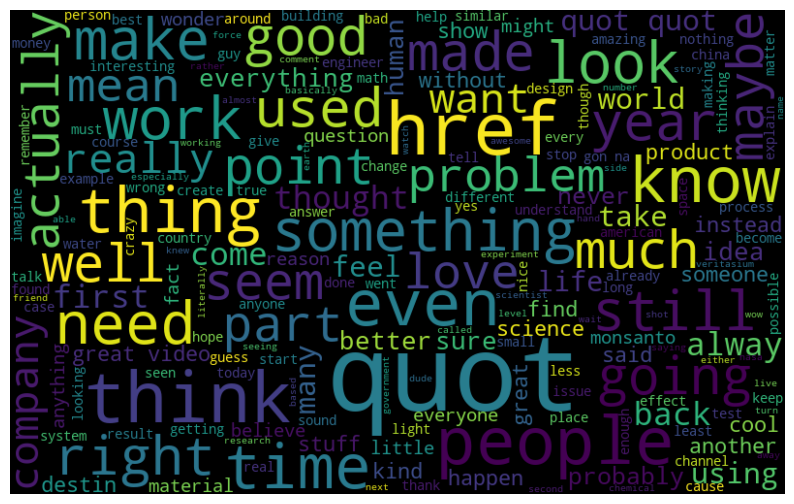

In [24]:
# Plotting cloudwords: to see how well the given sentiments are distributed across the dataset
from wordcloud import WordCloud
all_words = ' '.join([text for text in data['clean_text']])
wordcloud = WordCloud(width = 800, height = 500, random_state = 21, max_font_size = 110).generate(all_words)
plt.figure(figsize = (10, 7))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Words like love, well, good, thank, right, even, much, work are the most frequent ones, an indication that most words are positive or neutral.

b) Words in positive comments

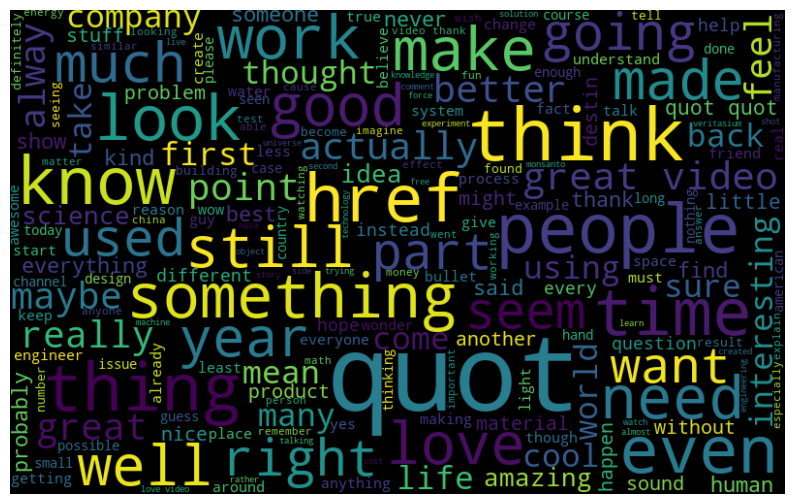

In [25]:
positive_words = ' '.join([text for text in data['clean_text'][data['sentiment'] == 1]])
wordcloud = WordCloud(width = 800, height = 500, random_state = 21, max_font_size = 110).generate(positive_words)
plt.figure(figsize = (10, 7))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Most frequent words like better, well, love, good, right, thank, amazing, great, much are compatible with the positive sentiment, i.e, positive comments

c) Words in neutral comments

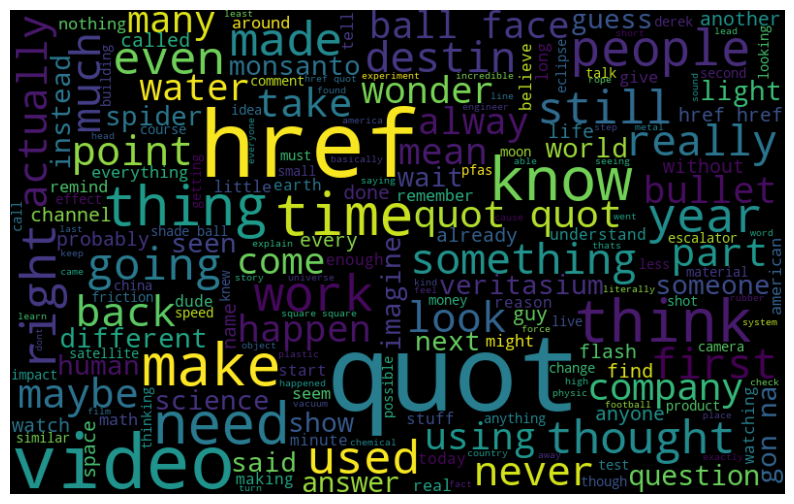

In [26]:
neutral_words = ' '.join([text for text in data['clean_text'][data['sentiment'] == 0]])
wordcloud = WordCloud(width = 800, height = 500, random_state = 21, max_font_size = 110).generate(neutral_words)
plt.figure(figsize = (10, 7))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Most words in neutral comments like even, alway, work, maybe, make, even have neutral implications.

d) Words in negative comments

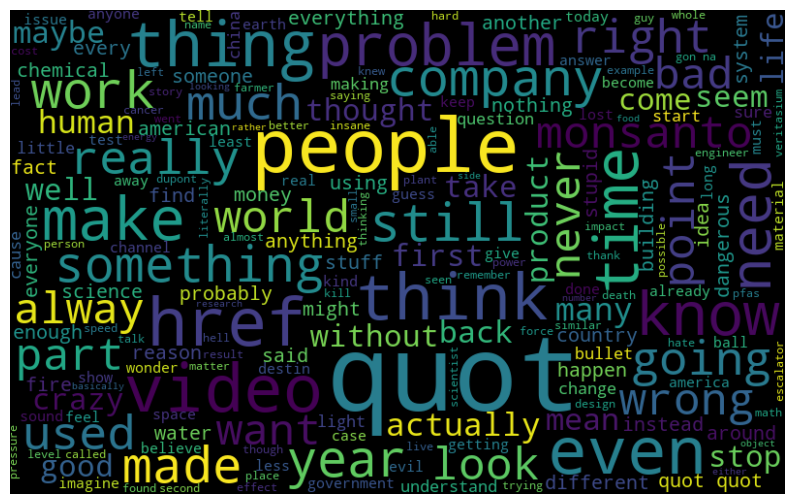

In [27]:
negative_words = ' '.join([text for text in data['clean_text'][data['sentiment'] == -1]])
wordcloud = WordCloud(width = 800, height = 500, random_state = 21, max_font_size = 110).generate(negative_words)
plt.figure(figsize = (10, 7))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Words like problem, wrong, bad, crazy, never have neutral implications.

Exploration

<Axes: xlabel='sentiment', ylabel='count'>

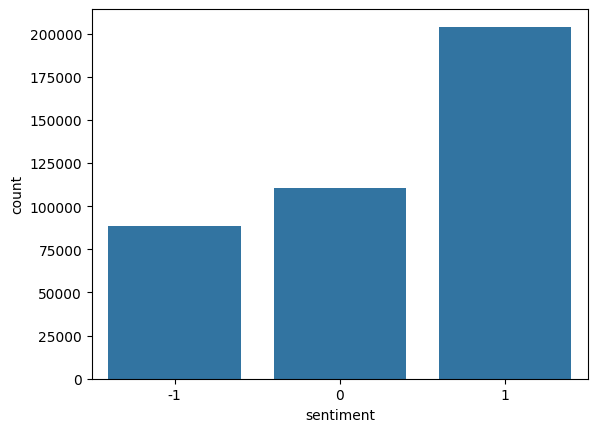

In [28]:
# Display the distribution of sentiment categories
sns.countplot(x='sentiment', data=data)

In [29]:
# Category-distribution of the dataset
label_counts = data['sentiment'].value_counts()
label_percentages = round((label_counts/label_counts.sum())*100, 2) # 2 d.p
label_info = pd.DataFrame({'Counts':label_counts,
                           'Percentages (%)':label_percentages})
print(label_info)

           Counts  Percentages (%)
sentiment                         
 1         203972            50.56
 0         110697            27.44
-1          88774            22.00


In [30]:
# Create a new column for word count
data['word_count'] = data['clean_text'].apply(lambda x: len(x.split()))
data.sample(5) # Display a few sample comments

,text,sentiment,clean_text,word_count
30223,"although gamma rays are usually higher energy than x-rays, that is not how they are seperated. there are high energy x-rays and low energy gamma rays that lead to an overlap of energies. they are ...",1,although gamma ray usually higher energy ray not seperated high energy ray energy gamma ray lead overlap energy seperated come gamma ray generated process nucleus ray process outside nuclues gener...,32
117377,why big rockets allways sound like a series of explosions,1,rocket allways sound like series explosion,6
124960,i think my cat is gonna ignore it 😂,1,think gon na ignore,4
149835,"why not just move the sheet of metal, instead of the robots?",0,not move sheet metal instead robot,6
363006,"when you check your blood levels by a blood drop, how you make sure to remove the trace from your akin and materials you touch before doing it.",1,check blood level blood drop make sure remove trace akin material touch,12


In [31]:
# Summary statistics for the word count
data['word_count'].describe()

count    403443.000000
mean         12.784473
std          20.290756
min           0.000000
25%           4.000000
50%           7.000000
75%          14.000000
max         925.000000
Name: word_count, dtype: float64

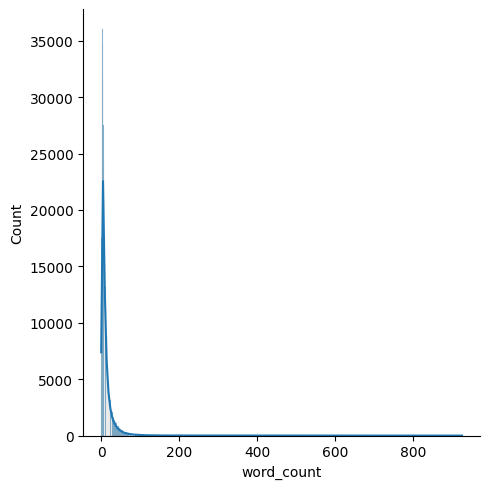

In [32]:
# Visualize the word count distribution
sns.displot(data['word_count'], kde=True)

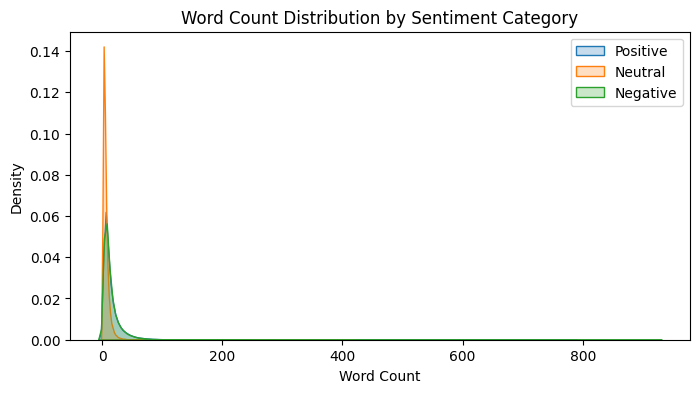

In [33]:
# Word count distribution by category/sentiment
# Create the figure and axes
plt.figure(figsize=(8, 4))

# Plot KDE for positive sentiment
sns.kdeplot(data[data['sentiment'] == 1]['word_count'], fill=True, label='Positive')

# Plot KDE for neutral sentiment
sns.kdeplot(data[data['sentiment'] == 0]['word_count'], fill=True, label='Neutral')

# Plot KDE for negative sentiment
sns.kdeplot(data[data['sentiment'] == -1]['word_count'], fill=True, label='Negative')

# Titles and labels
plt.title('Word Count Distribution by Sentiment Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

# Add legend
plt.legend()

# Show the plot
plt.show()

**Positive and Negative** comments tend to have a wider spread in word count indicating that longer comments are more common in positive/negative sentiments.

**Neutral** comments show relatively lower frequency and is more concentrated around shorter comments compared to positive or negative ones.

C:\Users\SirIsaac\AppData\Local\Temp\ipykernel_21456\1840510617.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=bigram_df, palette='magma')


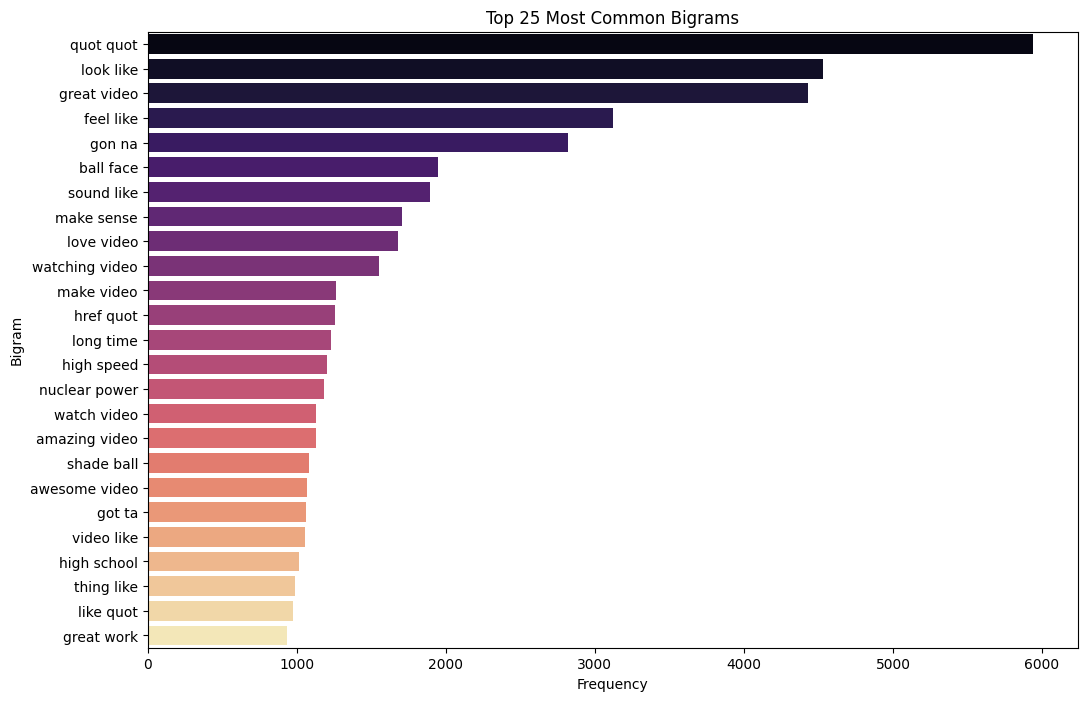

In [34]:
# Visualize the most frequent two-word combinations (bigrams) in the cleaned comments.
# This helps reveal common themes, repeated phrases, and patterns in how people express feedback.
from sklearn.feature_extraction.text import CountVectorizer

# Ctreate a function to extract the top 25 bigrams
def get_top_n_bigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams = get_top_n_bigrams(data['clean_text'], n=25)

# Convert to DataFrame for better visualization
bigram_df = pd.DataFrame(top_25_bigrams, columns=['Bigram', 'Frequency'])

# Plot the most common bigrams
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Bigram', data=bigram_df, palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

C:\Users\SirIsaac\AppData\Local\Temp\ipykernel_21456\4086688835.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Trigram', data=trigram_df, palette='coolwarm')


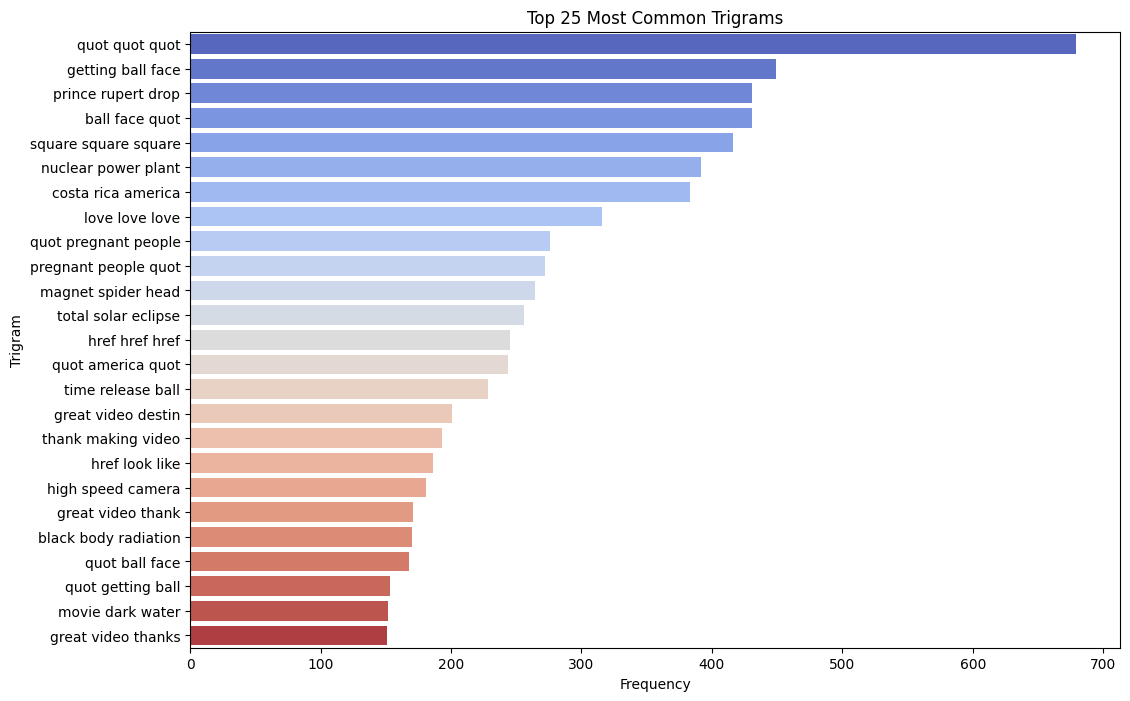

In [35]:
# Visualize the most frequent three-word combinations (trigrams) in the cleaned comments.
# Create a function to extract the top 25 trigrams
def get_top_n_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 trigrams
top_25_trigrams = get_top_n_trigrams(data['clean_text'], n=25)

# Convert to DataFrame for better visualization
trigram_df = pd.DataFrame(top_25_trigrams, columns=['Trigram', 'Frequency'])

# Plot the most common trigrams
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Trigram', data=trigram_df, palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.show()

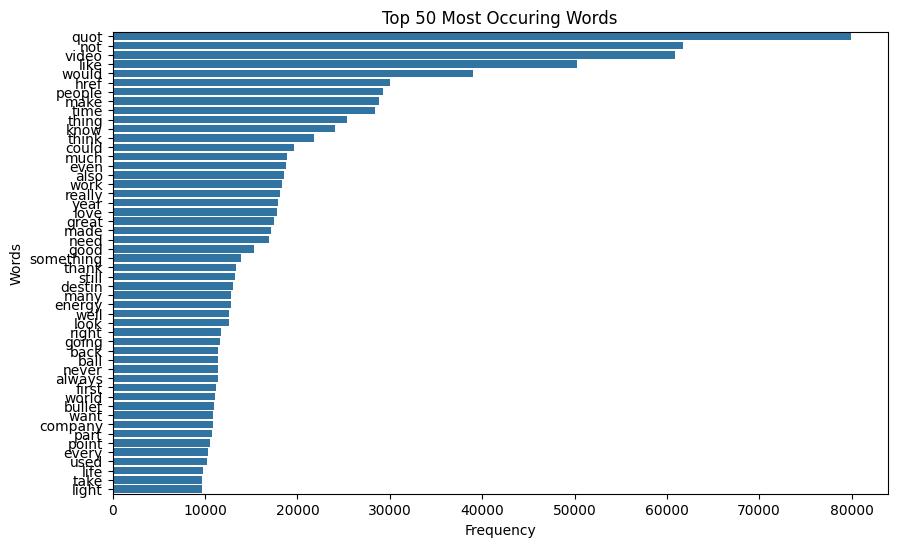

In [36]:
# Visualize most occuring words
from collections import Counter
def get_top_n_words(corpus, n=20):
    """Plot the top N most occuring words in the corpus"""
    # Flatten all words in the content clumn
    words = ' '.join(data['clean_text']).split()
    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their frequencies for plotting
    words, frequencies = zip(*most_common_words)

    # Plot the top N most common words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(frequencies), y=list(words))
    plt.title(f'Top {n} Most Occuring Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

# Example usage
get_top_n_words(data, n=50)

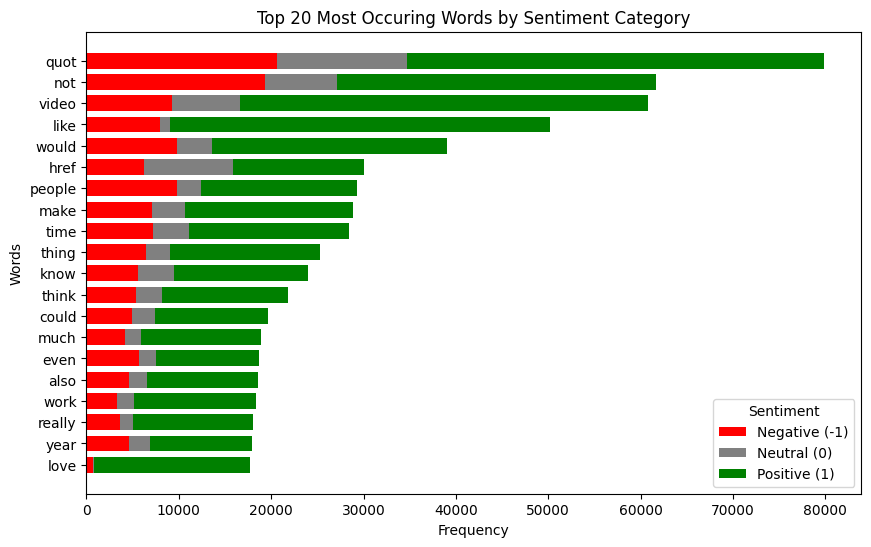

In [ ]:
# Visualize most occuring words by category/sentiment
def plot_top_n_words_by_category(data, n=20, start=0):
    """Plot the top N most occuring words in the dataset with stacked hue based on sentiment category"""
    # Flatten all words in the content column and their occurences by category
    word_category_counts = {}

    for idx, row in data.iterrows():
        words = row['clean_text'].split()
        category = row['sentiment'] # Assuming 'category' is the sentiment label
        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = {-1: 0, 0: 0, 1: 0} # Initialize counts for each category
            # Increment the count for the respective category
            word_category_counts[word][category] += 1
    # Gt total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # Get the top N most common words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start + start:n]
    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot the stacked bar chart
    plt.figure(figsize=(10, 6))
    bar_width = 0.75

    # Create bars for each category
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i, j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Occuring Words by Sentiment Category')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency on top
    plt.show()

# Example usage
plot_top_n_words_by_category(data)